<a href="https://colab.research.google.com/github/davinalifianda123/pengolahan_citra_smt4/blob/main/CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"davinalifiandaadytia","key":"0b5f74a7a2c8ccfd7fd4ac7ebe4bb5fa"}'}

In [ ]:
import os

# Pindahkan ke direktori .kaggle
os.makedirs("/root/.kaggle", exist_ok=True)
os.rename("kaggle.json", "/root/.kaggle/kaggle.json")
os.chmod("/root/.kaggle/kaggle.json", 0o600)

In [4]:
import kagglehub

# Download versi terbaru dari dataset
path = kagglehub.dataset_download("paramaggarwal/fashion-product-images-small")

print("Dataset berhasil diunduh ke path:", path)

100%|██████████| 565M/565M [00:14<00:00, 41.3MB/s]

Extracting files...


Dataset berhasil diunduh ke path: /root/.cache/kagglehub/datasets/paramaggarwal/fashion-product-images-small/versions/1


In [2]:
# Instalasi dan Import Library

import os

import cv2
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from PIL import Image

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import classification_report, confusion_matrix

Distribusi Kategori (masterCategory):
masterCategory
Apparel           21397
Accessories       11274
Footwear           9219
Personal Care      2403
Free Items          105
Sporting Goods       25
Home                  1
Name: count, dtype: int64


/tmp/ipython-input-5-4290655311.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.index, y=category_counts.values, palette='viridis')


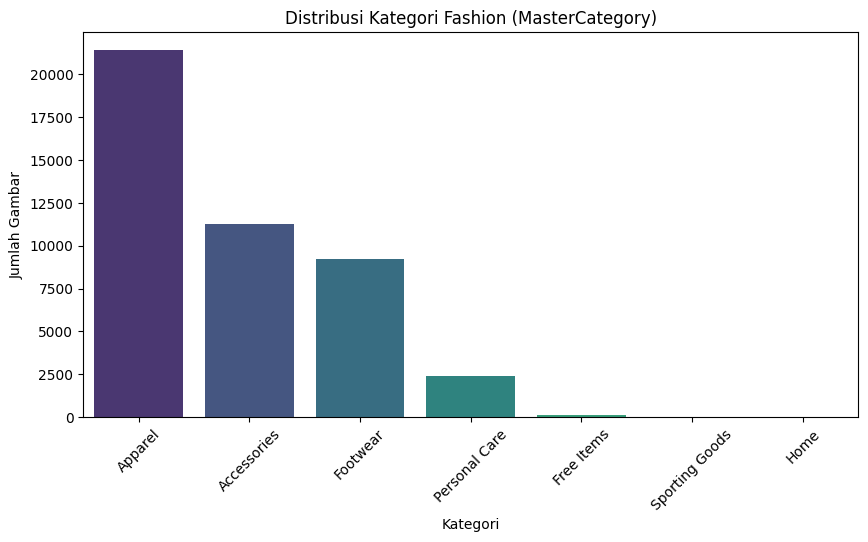

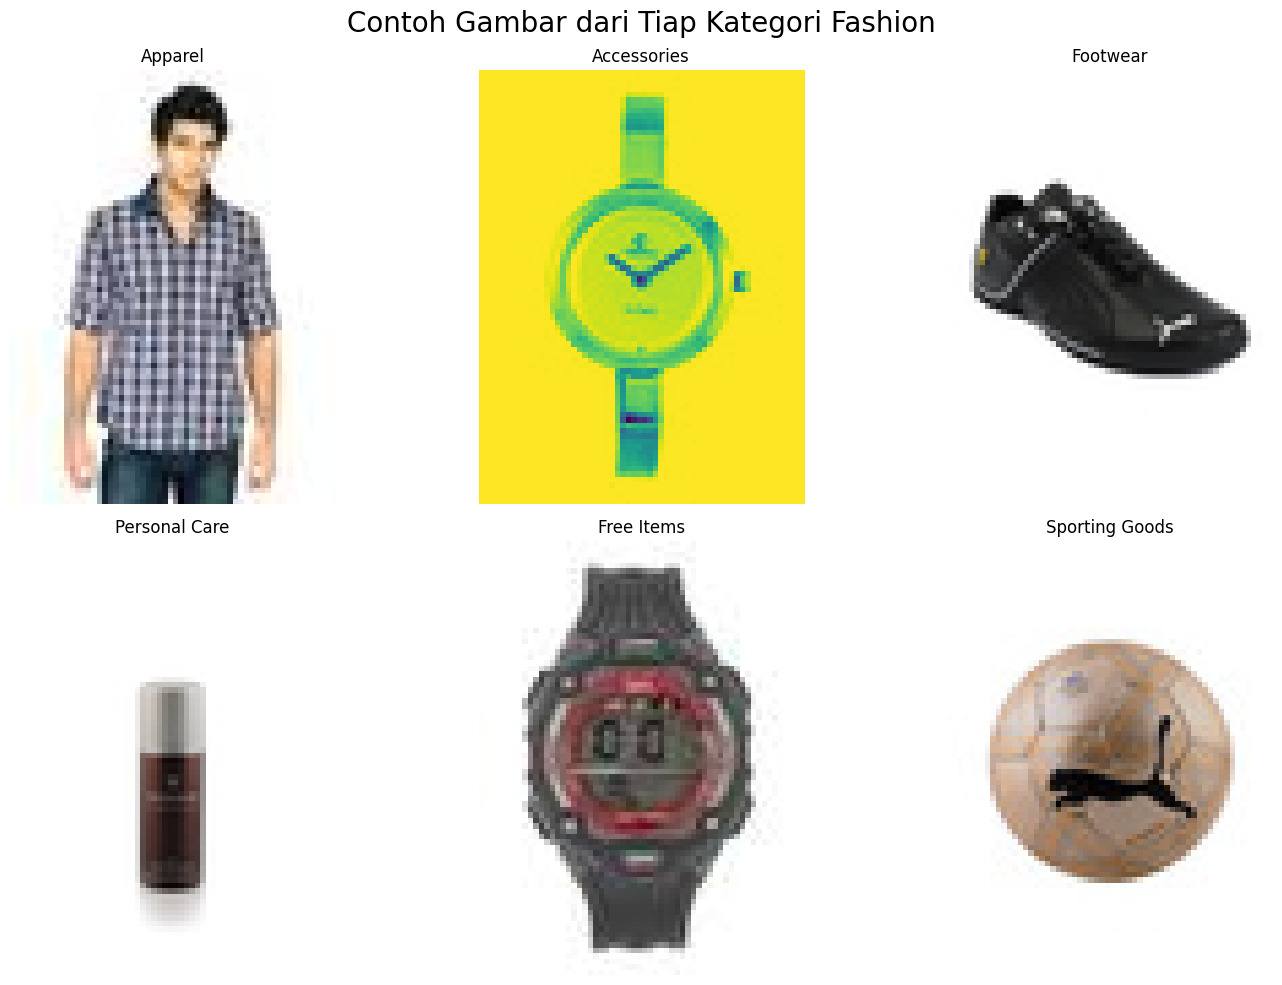

In [5]:
# Cell 2: Load Dataset dan EDA (untuk fashion dataset)

# Path hasil download dari kagglehub
base_dir = path  # path dari kagglehub.dataset_download()
image_dir = os.path.join(base_dir, 'images')
csv_path = os.path.join(base_dir, 'styles.csv')

# Load metadata CSV
df = pd.read_csv(csv_path, on_bad_lines='skip')  # skip baris rusak

# Drop baris tanpa kategori
df = df.dropna(subset=['gender', 'masterCategory', 'id'])

# Gunakan kolom masterCategory untuk klasifikasi utama
category_counts = df['masterCategory'].value_counts()
print("Distribusi Kategori (masterCategory):")
print(category_counts)

# Visualisasi distribusi
plt.figure(figsize=(10, 5))
sns.barplot(x=category_counts.index, y=category_counts.values, palette='viridis')
plt.title('Distribusi Kategori Fashion (MasterCategory)')
plt.ylabel('Jumlah Gambar')
plt.xlabel('Kategori')
plt.xticks(rotation=45)
plt.show()

# Tampilkan contoh gambar dari beberapa kategori populer
plt.figure(figsize=(15, 10))
popular_categories = category_counts.index[:6]

for i, cat in enumerate(popular_categories):
    img_id = df[df['masterCategory'] == cat].iloc[0]['id']
    img_path = os.path.join(image_dir, f"{img_id}.jpg")

    if os.path.exists(img_path):
        img = Image.open(img_path)
        plt.subplot(2, 3, i + 1)
        plt.imshow(img)
        plt.title(cat)
        plt.axis('off')

plt.suptitle('Contoh Gambar dari Tiap Kategori Fashion', size=20)
plt.tight_layout()
plt.show()

In [6]:

# Gunakan direktori dan file dari KaggleHub
image_dir = os.path.join(path, 'images')
csv_path = os.path.join(path, 'styles.csv')

# Load metadata
df = pd.read_csv(csv_path, on_bad_lines='skip')
df = df.dropna(subset=['masterCategory', 'id'])

# Gunakan 5 kategori terbanyak
categories = df['masterCategory'].value_counts().index[:5]
df = df[df['masterCategory'].isin(categories)]

# Tambahkan ekstensi .jpg ke kolom ID agar cocok dengan nama file gambar
df['id'] = df['id'].astype(str) + ".jpg"

# Verifikasi apakah file gambar benar-benar ada
df['file_exists'] = df['id'].apply(lambda x: os.path.exists(os.path.join(image_dir, x)))
df = df[df['file_exists'] == True]
df = df.drop(columns='file_exists')

# Normalisasi dan split data
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

IMG_SIZE = (96, 96)
BATCH_SIZE = 32

# Generator data training
train_gen = datagen.flow_from_dataframe(
    dataframe=df,
    directory=image_dir,
    x_col='id',
    y_col='masterCategory',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    classes=list(categories)
)

# Generator data validasi
val_gen = datagen.flow_from_dataframe(
    dataframe=df,
    directory=image_dir,
    x_col='id',
    y_col='masterCategory',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=True,
    classes=list(categories)
)

Found 35515 validated image filenames belonging to 5 classes.
Found 8878 validated image filenames belonging to 5 classes.


In [7]:
# Gunakan jumlah kelas dan shape sesuai dengan generator
input_shape = (IMG_SIZE[0], IMG_SIZE[1], 3)  # RGB = 3 channel
num_classes = len(categories)  # 5 kategori fashion

def create_cnn_model(input_shape, num_classes):
    model = Sequential([
        Input(shape=input_shape),

        # Blok Konvolusi 1
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),

        # Blok Konvolusi 2
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),

        # Blok Konvolusi 3
        Conv2D(256, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),

        # Flatten dan Fully Connected Layer
        Flatten(),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),

        # Output Layer
        Dense(num_classes, activation='softmax')
    ])

    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Buat dan tampilkan ringkasan model
model = create_cnn_model(input_shape, num_classes)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 96, 96, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 96, 96, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 96, 96, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 96, 96, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 48, 48, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 48, 48, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     9,437,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,830,085 (37.50 MB)

 Trainable params: 9,828,613 (37.49 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [9]:
N_SPLITS = 3
EPOCHS = 100
BATCH_SIZE = 32

kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

fold_accuracies = []
fold_histories = []

for fold, (train_index, val_index) in enumerate(kf.split(df)):
    print(f"\n===== FOLD {fold + 1}/{N_SPLITS} =====")

    # Split dataframe berdasarkan index fold
    train_df = df.iloc[train_index]
    val_df = df.iloc[val_index]

    # Buat ulang generator untuk setiap fold
    train_gen = datagen.flow_from_dataframe(
        dataframe=train_df,
        directory=image_dir,
        x_col='id',
        y_col='masterCategory',
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=True,
        classes=list(categories)
    )

    val_gen = datagen.flow_from_dataframe(
        dataframe=val_df,
        directory=image_dir,
        x_col='id',
        y_col='masterCategory',
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=False,
        classes=list(categories)
    )

    # Buat model baru
    model = create_cnn_model((IMG_SIZE[0], IMG_SIZE[1], 3), len(categories))

    # Callback untuk early stopping
    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )

    # Training
    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=EPOCHS,
        callbacks=[early_stopping],
        verbose=1
    )

    # Evaluasi
    val_loss, val_acc = model.evaluate(val_gen, verbose=0)
    print(f"Akurasi Validasi Fold {fold + 1}: {val_acc * 100:.2f}%")

    fold_accuracies.append(val_acc)
    fold_histories.append(history)

# Ringkasan hasil
print("\n===== HASIL K-FOLD CROSS-VALIDATION =====")
for i, acc in enumerate(fold_accuracies):
    print(f"Akurasi Fold {i+1}: {acc * 100:.2f}%")

print(f"\nRata-rata Akurasi Validasi: {np.mean(fold_accuracies) * 100:.2f}%")
print(f"Standar Deviasi Akurasi: {np.std(fold_accuracies) * 100:.2f}%")



===== FOLD 1/3 =====
Found 29595 validated image filenames belonging to 5 classes.
Found 14798 validated image filenames belonging to 5 classes.
Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


925/925 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9038 - loss: 0.3176

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


925/925 ━━━━━━━━━━━━━━━━━━━━ 61s 55ms/step - accuracy: 0.9039 - loss: 0.3175 - val_accuracy: 0.4880 - val_loss: 14.7690
Epoch 2/100
925/925 ━━━━━━━━━━━━━━━━━━━━ 44s 47ms/step - accuracy: 0.9503 - loss: 0.1674 - val_accuracy: 0.7912 - val_loss: 0.5666
Epoch 3/100
925/925 ━━━━━━━━━━━━━━━━━━━━ 44s 48ms/step - accuracy: 0.9666 - loss: 0.1178 - val_accuracy: 0.6369 - val_loss: 2.0142
Epoch 4/100
925/925 ━━━━━━━━━━━━━━━━━━━━ 45s 49ms/step - accuracy: 0.9711 - loss: 0.0996 - val_accuracy: 0.9655 - val_loss: 0.1241
Epoch 5/100
925/925 ━━━━━━━━━━━━━━━━━━━━ 44s 48ms/step - accuracy: 0.9768 - loss: 0.0839 - val_accuracy: 0.9511 - val_loss: 0.1563
Epoch 6/100
925/925 ━━━━━━━━━━━━━━━━━━━━ 45s 49ms/step - accuracy: 0.9664 - loss: 0.1191 - val_accuracy: 0.5948 - val_loss: 6.8329
Epoch 7/100
925/925 ━━━━━━━━━━━━━━━━━━━━ 44s 47ms/step - accuracy: 0.9747 - loss: 0.0862 - val_accuracy: 0.8957 - val_loss: 0.4097
Epoch 8/100
925/925 ━━━━━━━━━━━━━━━━━━━━ 44s 48ms/step - accuracy: 0.9842 - loss: 0.0602 - val

...

925/925 ━━━━━━━━━━━━━━━━━━━━ 60s 55ms/step - accuracy: 0.8954 - loss: 0.3607 - val_accuracy: 0.9684 - val_loss: 0.1157
Epoch 2/100
925/925 ━━━━━━━━━━━━━━━━━━━━ 45s 49ms/step - accuracy: 0.9584 - loss: 0.1480 - val_accuracy: 0.9764 - val_loss: 0.0888
Epoch 3/100
925/925 ━━━━━━━━━━━━━━━━━━━━ 44s 48ms/step - accuracy: 0.9704 - loss: 0.1018 - val_accuracy: 0.9084 - val_loss: 0.3383
Epoch 4/100
925/925 ━━━━━━━━━━━━━━━━━━━━ 45s 48ms/step - accuracy: 0.9660 - loss: 0.1138 - val_accuracy: 0.9705 - val_loss: 0.1047
Epoch 5/100
925/925 ━━━━━━━━━━━━━━━━━━━━ 44s 47ms/step - accuracy: 0.9753 - loss: 0.0839 - val_accuracy: 0.5132 - val_loss: 11.7318
Epoch 6/100
925/925 ━━━━━━━━━━━━━━━━━━━━ 44s 47ms/step - accuracy: 0.9746 - loss: 0.0894 - val_accuracy: 0.9547 - val_loss: 0.1556
Epoch 7/100
925/925 ━━━━━━━━━━━━━━━━━━━━ 43s 47ms/step - accuracy: 0.9831 - loss: 0.0594 - val_accuracy: 0.7095 - val_loss: 1.8603
Akurasi Validasi Fold 2: 97.64%

===== FOLD 3/3 =====
Found 29596 validated image filenames be

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


925/925 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.9026 - loss: 0.3437

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


925/925 ━━━━━━━━━━━━━━━━━━━━ 64s 59ms/step - accuracy: 0.9026 - loss: 0.3436 - val_accuracy: 0.9243 - val_loss: 0.3320
Epoch 2/100
925/925 ━━━━━━━━━━━━━━━━━━━━ 44s 47ms/step - accuracy: 0.9634 - loss: 0.1329 - val_accuracy: 0.8567 - val_loss: 0.4238
Epoch 3/100
925/925 ━━━━━━━━━━━━━━━━━━━━ 43s 47ms/step - accuracy: 0.9707 - loss: 0.1084 - val_accuracy: 0.7335 - val_loss: 1.0887
Epoch 4/100
925/925 ━━━━━━━━━━━━━━━━━━━━ 44s 47ms/step - accuracy: 0.9744 - loss: 0.0933 - val_accuracy: 0.8927 - val_loss: 0.4825
Epoch 5/100
925/925 ━━━━━━━━━━━━━━━━━━━━ 44s 47ms/step - accuracy: 0.9763 - loss: 0.0840 - val_accuracy: 0.7979 - val_loss: 0.6269
Epoch 6/100
925/925 ━━━━━━━━━━━━━━━━━━━━ 44s 48ms/step - accuracy: 0.9767 - loss: 0.0816 - val_accuracy: 0.9586 - val_loss: 0.1811
Epoch 7/100
925/925 ━━━━━━━━━━━━━━━━━━━━ 45s 48ms/step - accuracy: 0.9776 - loss: 0.0788 - val_accuracy: 0.8073 - val_loss: 1.1045
Epoch 8/100
925/925 ━━━━━━━━━━━━━━━━━━━━ 81s 47ms/step - accuracy: 0.9860 - loss: 0.0534 - val_

In [14]:
# 1. Split DataFrame menjadi train/test
train_val_df, test_df = train_test_split(df, test_size=0.2, stratify=df['masterCategory'], random_state=42)
train_df, val_df = train_test_split(train_val_df, test_size=0.1, stratify=train_val_df['masterCategory'], random_state=42)


# 2. Generator Train dan Test
train_gen = datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=image_dir,
    x_col='id',
    y_col='masterCategory',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    classes=list(categories)
)

val_gen = datagen.flow_from_dataframe(
    dataframe=val_df,
    directory=image_dir,
    x_col='id',
    y_col='masterCategory',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    classes=list(categories)
)

# 3. Bangun dan latih model akhir
print("\nMelatih model akhir pada train split...")
final_model = create_cnn_model((IMG_SIZE[0], IMG_SIZE[1], 3), len(categories))
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_final = final_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=100,
    callbacks=[early_stopping],
    verbose=1
)

# 4. Simpan model
final_model.save("final_cnn_fashion_model.h5")
print("\nModel disimpan sebagai 'final_cnn_fashion_model.h5'")

Found 31962 validated image filenames belonging to 5 classes.
Found 3552 validated image filenames belonging to 5 classes.

Melatih model akhir pada train split...
Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


999/999 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9156 - loss: 0.2958

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


999/999 ━━━━━━━━━━━━━━━━━━━━ 54s 45ms/step - accuracy: 0.9157 - loss: 0.2957 - val_accuracy: 0.1168 - val_loss: 6.0014
Epoch 2/100
999/999 ━━━━━━━━━━━━━━━━━━━━ 41s 41ms/step - accuracy: 0.9585 - loss: 0.1547 - val_accuracy: 0.8668 - val_loss: 0.3106
Epoch 3/100
999/999 ━━━━━━━━━━━━━━━━━━━━ 40s 40ms/step - accuracy: 0.9731 - loss: 0.0998 - val_accuracy: 0.8407 - val_loss: 0.7145
Epoch 4/100
999/999 ━━━━━━━━━━━━━━━━━━━━ 41s 41ms/step - accuracy: 0.9752 - loss: 0.0911 - val_accuracy: 0.8702 - val_loss: 0.4879
Epoch 5/100
999/999 ━━━━━━━━━━━━━━━━━━━━ 41s 40ms/step - accuracy: 0.9830 - loss: 0.0645 - val_accuracy: 0.5287 - val_loss: 7.5039
Epoch 6/100
999/999 ━━━━━━━━━━━━━━━━━━━━ 40s 40ms/step - accuracy: 0.9805 - loss: 0.0691 - val_accuracy: 0.9707 - val_loss: 0.0937
Epoch 7/100
999/999 ━━━━━━━━━━━━━━━━━━━━ 40s 40ms/step - accuracy: 0.9869 - loss: 0.0509 - val_accuracy: 0.9651 - val_loss: 0.2012
Epoch 8/100
999/999 ━━━━━━━━━━━━━━━━━━━━ 40s 40ms/step - accuracy: 0.9890 - loss: 0.0399 - val_


Model disimpan sebagai 'final_cnn_fashion_model.h5'

===== EVALUASI MODEL PADA DATA TEST =====



===== EVALUASI MODEL PADA DATA TEST =====


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Akurasi pada Data Test: 97.41%
Loss pada Data Test: 0.0912
8879/8879 ━━━━━━━━━━━━━━━━━━━━ 29s 3ms/step

Laporan Klasifikasi:
               precision    recall  f1-score   support

      Apparel       0.99      0.98      0.98      4278
  Accessories       0.93      0.98      0.95      2255
     Footwear       1.00      0.98      0.99      1844
Personal Care       0.98      0.92      0.95       481
   Free Items       0.00      0.00      0.00        21

     accuracy                           0.97      8879
    macro avg       0.78      0.77      0.78      8879
 weighted avg       0.97      0.97      0.97      8879



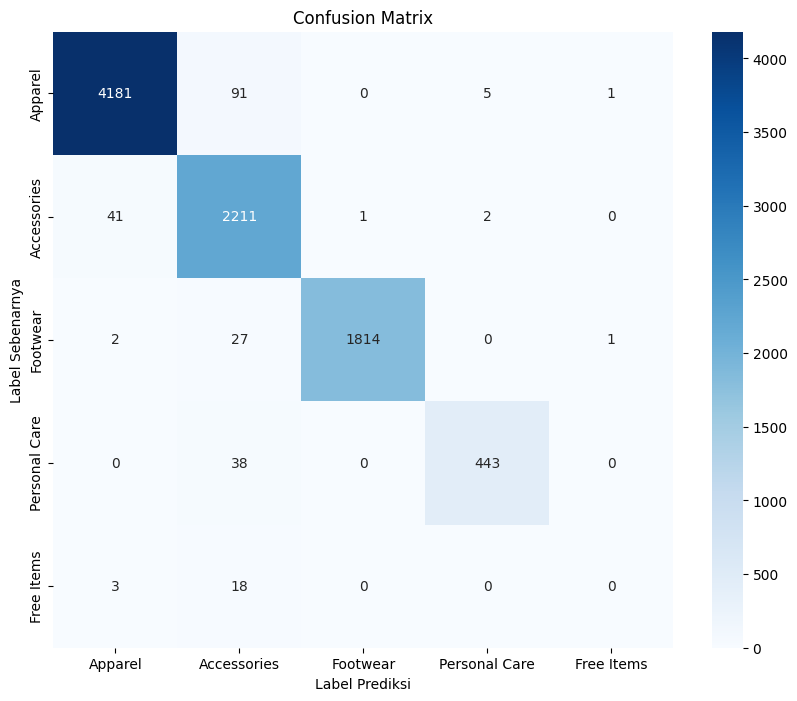

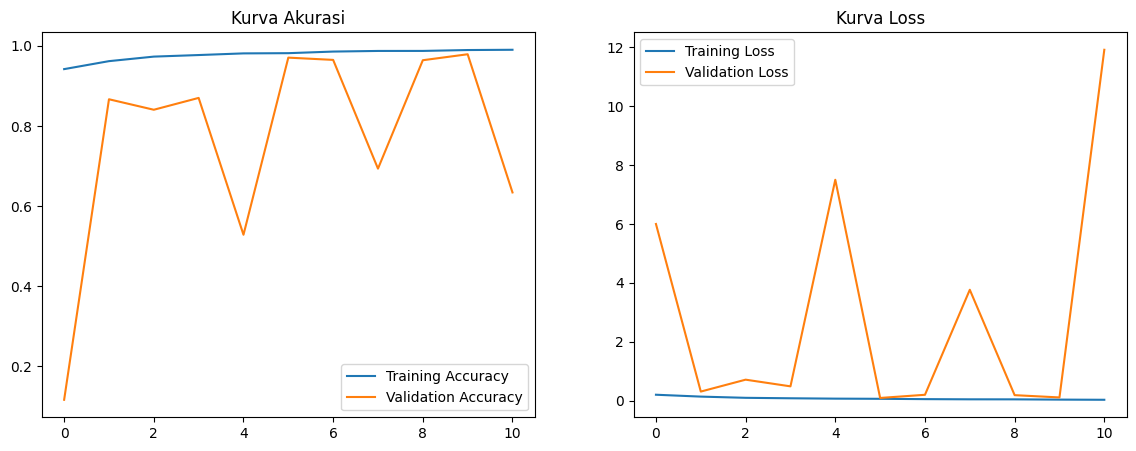

In [15]:
# 5. Evaluasi Model pada Test Set
print("\n===== EVALUASI MODEL PADA DATA TEST =====")
test_loss, test_acc = final_model.evaluate(test_gen, verbose=0)
print(f"Akurasi pada Data Test: {test_acc * 100:.2f}%")
print(f"Loss pada Data Test: {test_loss:.4f}")

# 6. Prediksi & Laporan Evaluasi
y_true = test_gen.classes
y_pred_probs = final_model.predict(test_gen)
y_pred = np.argmax(y_pred_probs, axis=1)

# Nama label
label_names = list(categories)

print("\nLaporan Klasifikasi:")
print(classification_report(y_true, y_pred, target_names=label_names))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
plt.title('Confusion Matrix')
plt.ylabel('Label Sebenarnya')
plt.xlabel('Label Prediksi')
plt.show()

# 7. Kurva Akurasi dan Loss
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(history_final.history['accuracy'], label='Training Accuracy')
plt.plot(history_final.history['val_accuracy'], label='Validation Accuracy')
plt.title('Kurva Akurasi')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history_final.history['loss'], label='Training Loss')
plt.plot(history_final.history['val_loss'], label='Validation Loss')
plt.title('Kurva Loss')
plt.legend()
plt.show()

In [22]:
import requests
from tensorflow.keras.models import load_model

# Muat model fashion yang telah disimpan
try:
    loaded_model = load_model('final_cnn_fashion_model.h5')
    print("\nModel 'final_cnn_fashion_model.h5' berhasil dimuat.")
except Exception as e:
    print(f"Error saat memuat model: {e}")
    loaded_model = None

# Daftar kategori fashion (harus sesuai urutan `categories`)
label_names = list(categories)
IMG_SIZE = 96  # sesuai dengan training


Model 'final_cnn_fashion_model.h5' berhasil dimuat.


In [23]:
def predict_fashion_from_file(image_path, model):
    if model is None:
        print("Model tidak tersedia untuk prediksi.")
        return

    try:
        # 1. Load dan tampilkan gambar
        img = Image.open(image_path).convert('RGB')
        plt.imshow(img)
        plt.title("Gambar Input")
        plt.axis('off')
        plt.show()

        # 2. Resize dan preprocessing
        img_resized = img.resize((IMG_SIZE, IMG_SIZE))
        img_array = np.array(img_resized) / 255.0
        img_input = np.expand_dims(img_array, axis=0)

        # 3. Prediksi
        prediction = model.predict(img_input)
        predicted_index = np.argmax(prediction)
        predicted_label = label_names[predicted_index]
        confidence = np.max(prediction) * 100

        print(f"\nPrediksi Kategori: {predicted_label}")
        print(f"Tingkat Keyakinan: {confidence:.2f}%")

        # 4. Visualisasi probabilitas
        plt.figure(figsize=(8, 4))
        sns.barplot(x=label_names, y=prediction[0], palette='viridis')
        plt.title('Probabilitas Prediksi per Kategori')
        plt.ylabel('Probabilitas')
        plt.xlabel('Kategori')
        plt.xticks(rotation=45)
        plt.show()

    except Exception as e:
        print(f"Terjadi error saat memproses gambar: {e}")

In [27]:
# Misal kamu upload gambar ke Colab, gunakan:
from google.colab import files
uploaded = files.upload()  # pilih file gambar dari lokal

Saving sepatu2.webp to sepatu2.webp


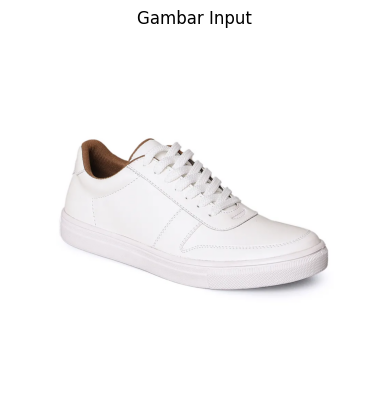

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step

Prediksi Kategori: Footwear
Tingkat Keyakinan: 99.35%


/tmp/ipython-input-23-654930973.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_names, y=prediction[0], palette='viridis')


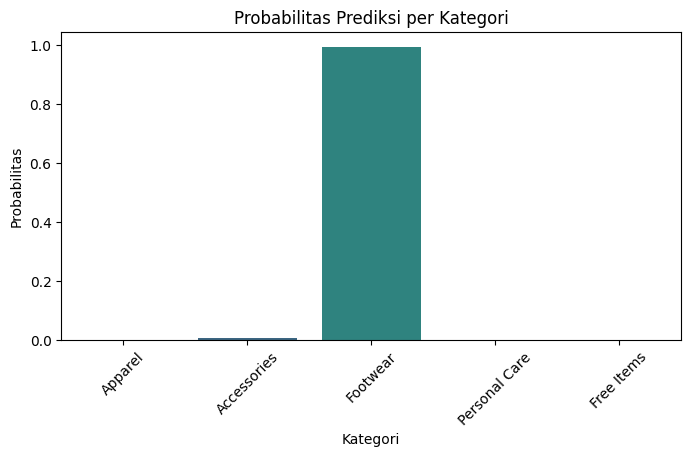

In [28]:
# Prediksi (ganti dengan nama file yang kamu upload)
predict_fashion_from_file("sepatu2.webp", loaded_model)

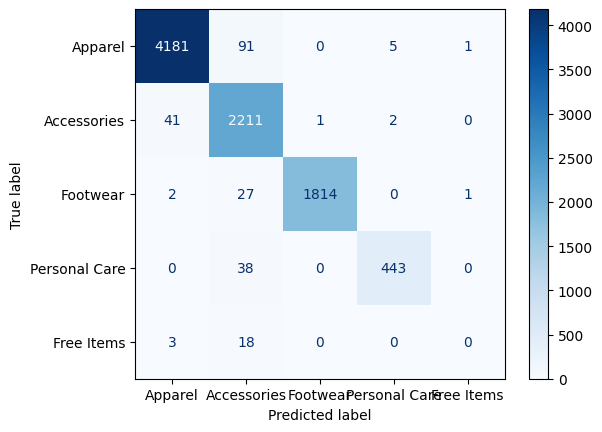

In [32]:
# Prediksi (ganti dengan nama file yang kamu upload)
predict_fashion_from_file("jeans.webp", loaded_model)